# Data: findings, views, films per patient, and the CTR check

**Question.** What does the NIH ChestX-ray14 data behind this project look like (findings, views, films
per patient, mask quality), and does the cardiothoracic ratio (CTR), measured on the CheXmask contours,
separate cardiomegaly films from normal films on PA views, as physiology says it should?

**Data.** `outputs/ctr_nih.csv`: one row per NIH film, written by `python -m cxr.data ctr` on the pod
(labels from `Data_Entry_2017_v2020.csv`, CTR from the CheXmask landmarks). It is copied to the Mac and
kept out of git; everything else comes from `results/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image

ROOT = Path.cwd().parent  # the notebook runs from notebooks/
sys.path.insert(0, str(ROOT))
from cxr.data import AXIS, GRID, INK, INK_2, MUTED, SURFACE, auroc

films = pd.read_csv(ROOT / "outputs" / "ctr_nih.csv")
print(f"{len(films):,} films from {films['patient_id'].nunique():,} patients")

112,120 films from 30,805 patients


## Views

The CTR rule (a heart wider than half the chest is enlarged) holds on PA films. On AP films the heart
is magnified, so the edits and the audit use PA films only.

In [2]:
views = films["view"].value_counts()
print(views.to_string())
print(f"\nPA films: {views['PA']:,} ({views['PA'] / len(films):.1%} of all films)")

view
PA    67310
AP    44810

PA films: 67,310 (60.0% of all films)


## Findings

The labels were mined from the radiology reports, so they are noisy. A film can carry several findings;
*no finding* means none of the 14 NIH findings.

In [3]:
findings = ["cardiomegaly", "effusion", "pneumothorax", "no_finding"]
table = pd.DataFrame({view: films.loc[films["view"] == view, findings].sum() for view in ["PA", "AP"]})
for view in ["PA", "AP"]:
    table[f"{view} %"] = (100 * table[view] / views[view]).round(1)
print(table.to_string())

                 PA     AP  PA %  AP %
cardiomegaly   1563   1213   2.3   2.7
effusion       6589   6728   9.8  15.0
pneumothorax   3407   1895   5.1   4.2
no_finding    39302  21059  58.4  47.0


## Films per patient

Many patients have several films (follow-up visits). Films of one patient are not independent, so the
train / val / test split is by patient and every confidence interval resamples patients.

In [4]:
per_patient = films.groupby("patient_id").size()
print(f"films per patient: median {per_patient.median():.0f}, 90th percentile "
      f"{per_patient.quantile(0.9):.0f}, max {per_patient.max()}")
print(f"{(per_patient == 1).mean():.1%} of patients have a single film, but "
      f"{per_patient[per_patient > 1].sum() / len(films):.1%} of films come from patients with two or more")

films per patient: median 1, 90th percentile 8, max 184
56.8% of patients have a single film, but 84.4% of films come from patients with two or more


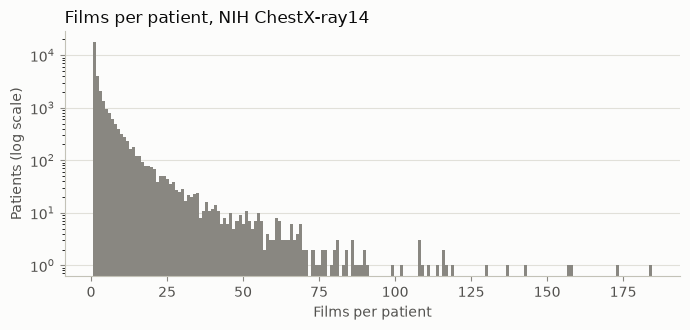

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.4), facecolor=SURFACE)
ax.hist(per_patient, bins=np.arange(0.5, per_patient.max() + 1.5), color=MUTED)
ax.set_yscale("log")
ax.set_xlabel("Films per patient", color=INK_2)
ax.set_ylabel("Patients (log scale)", color=INK_2)
ax.set_title("Films per patient, NIH ChestX-ray14", loc="left", color=INK)
ax.set_facecolor(SURFACE)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, labelcolor=INK_2)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color(AXIS)
fig.tight_layout()
fig.savefig(ROOT / "results" / "data_films_per_patient.png", dpi=200, facecolor=SURFACE)
plt.show()

## Mask quality

CheXmask estimates the quality of each mask (Dice RCA). As its authors advise, only masks with
Dice RCA ≥ 0.7 are used.

In [6]:
print(f"{films['good_mask'].mean():.1%} of films have a mask with Dice RCA >= 0.7; by view:")
print(films.groupby("view")["good_mask"].mean().map("{:.1%}".format).to_string())

98.8% of films have a mask with Dice RCA >= 0.7; by view:
view
AP    97.5%
PA    99.7%


## CTR physiology check

On PA films the CTR should separate cardiomegaly from normal films; on AP films the heart looks bigger,
so normal films often exceed 0.5. The numbers are recomputed from the per-image table and checked
against `results/ctr_summary.csv`; the AUROC then gets a 95% confidence interval that resamples patients.

In [7]:
good = films[films["good_mask"]]
summary = pd.read_csv(ROOT / "results" / "ctr_summary.csv").set_index(["view", "group"])
rows = {}
for view in ["PA", "AP"]:
    d = good[good["view"] == view]
    cardio, normal = d.loc[d["cardiomegaly"] == 1, "ctr"], d.loc[d["no_finding"] == 1, "ctr"]
    rows[view] = {"cardiomegaly > 0.5": (cardio > 0.5).mean(), "normal > 0.5": (normal > 0.5).mean(),
                  "auroc": auroc(cardio.to_numpy(), normal.to_numpy())}
    row = summary.loc[(view, "Cardiomegaly")]
    assert np.isclose(100 * rows[view]["cardiomegaly > 0.5"], row["pct_ctr_above_0.5"], atol=1e-3)
    assert np.isclose(rows[view]["auroc"], row["auroc_vs_no_finding"], atol=1e-3)
check = pd.DataFrame(rows).T
print(check.round(3).to_string())
print("\nSame values as results/ctr_summary.csv")

    cardiomegaly > 0.5  normal > 0.5  auroc
PA               0.884         0.186  0.914
AP               0.917         0.519  0.795

Same values as results/ctr_summary.csv


In [8]:
def auroc_ci(d, n_boot=1000, seed=0):
    """95% CI of the CTR AUROC (cardiomegaly vs no finding), resampling patients with replacement."""
    d = d[(d["cardiomegaly"] == 1) | (d["no_finding"] == 1)]
    patient = pd.factorize(d["patient_id"])[0]
    n_patients = patient.max() + 1
    ctr, label = d["ctr"].to_numpy(), d["cardiomegaly"].to_numpy()
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        times = np.bincount(rng.integers(n_patients, size=n_patients), minlength=n_patients)
        rows = np.repeat(np.arange(len(d)), times[patient])  # each film as often as its patient was drawn
        boots.append(auroc(ctr[rows][label[rows] == 1], ctr[rows][label[rows] == 0]))
    return np.percentile(boots, [2.5, 97.5])

ci = {view: auroc_ci(good[good["view"] == view]) for view in ["PA", "AP"]}
pd.DataFrame({"view": ["PA", "AP"], "auroc": [check.loc[v, "auroc"] for v in ["PA", "AP"]],
              "ci_low": [ci[v][0] for v in ["PA", "AP"]], "ci_high": [ci[v][1] for v in ["PA", "AP"]]}
             ).round(3).to_csv(ROOT / "results" / "ctr_auroc_ci.csv", index=False)
for view in ["PA", "AP"]:
    print(f"{view}: AUROC {check.loc[view, 'auroc']:.3f} (95% CI {ci[view][0]:.3f}-{ci[view][1]:.3f}); "
          f"CTR > 0.5 in {check.loc[view, 'cardiomegaly > 0.5']:.1%} of cardiomegaly films vs "
          f"{check.loc[view, 'normal > 0.5']:.1%} of normal films")

PA: AUROC 0.914 (95% CI 0.908-0.921); CTR > 0.5 in 88.4% of cardiomegaly films vs 18.6% of normal films
AP: AUROC 0.795 (95% CI 0.778-0.811); CTR > 0.5 in 91.7% of cardiomegaly films vs 51.9% of normal films


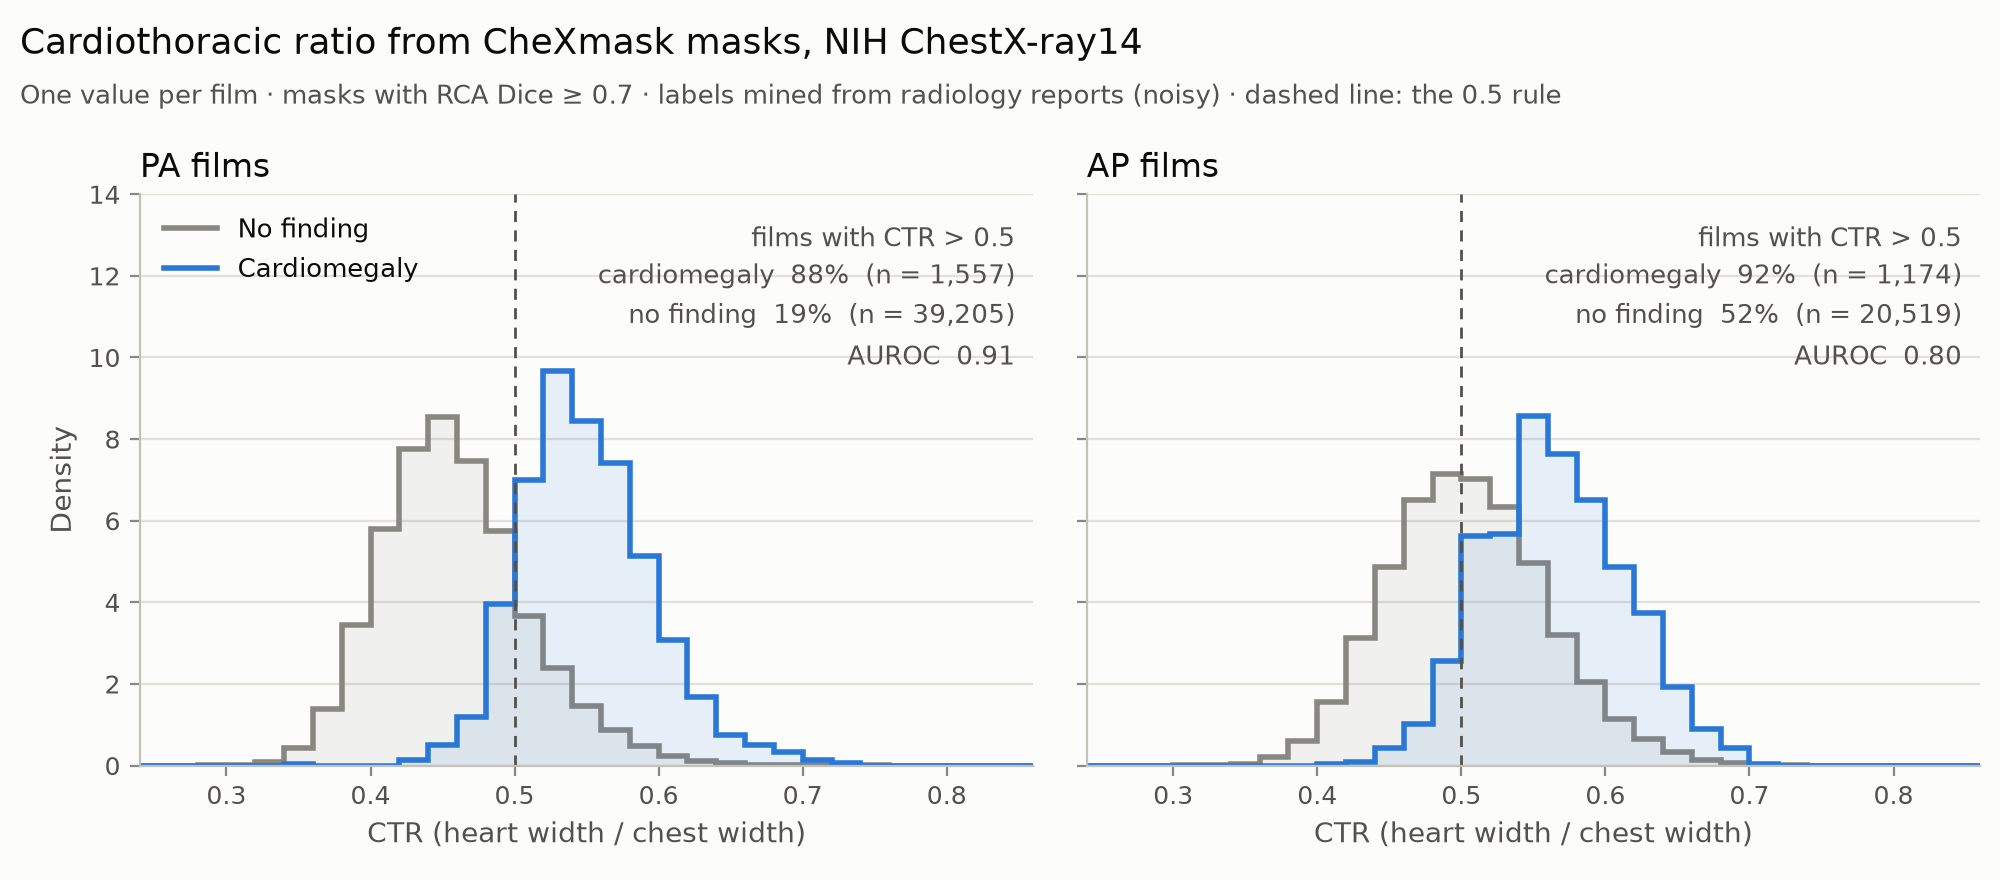

In [9]:
Image(filename=str(ROOT / "results" / "ctr_by_view.png"), width=900)

## Takeaways

In [10]:
pa = films[films["view"] == "PA"]
print("\n".join([
    f"1. {views['PA']:,} of {len(films):,} films are PA. Edits and audit use PA only: on AP films "
    f"{check.loc['AP', 'normal > 0.5']:.0%} of normal films already have a CTR above 0.5.",
    f"2. PA films with cardiomegaly: {pa['cardiomegaly'].sum():,}; effusion: {pa['effusion'].sum():,}; "
    f"pneumothorax: {pa['pneumothorax'].sum():,}; no finding: {pa['no_finding'].sum():,}. The labels are "
    "mined from reports, so they are noisy.",
    f"3. {per_patient[per_patient > 1].sum() / len(films):.0%} of films come from patients with several films: "
    "splits and confidence intervals must work by patient.",
    f"4. {films['good_mask'].mean():.0%} of films have a usable CheXmask mask (Dice RCA >= 0.7).",
    f"5. On PA films the CTR separates cardiomegaly from normal films with AUROC {check.loc['PA', 'auroc']:.2f} "
    f"(95% CI {ci['PA'][0]:.2f}-{ci['PA'][1]:.2f}), against {check.loc['AP', 'auroc']:.2f} on AP films: "
    "the CTR is a sound anatomical check for cardiomegaly edits on PA films.",
]))

1. 67,310 of 112,120 films are PA. Edits and audit use PA only: on AP films 52% of normal films already have a CTR above 0.5.
2. PA films with cardiomegaly: 1,563; effusion: 6,589; pneumothorax: 3,407; no finding: 39,302. The labels are mined from reports, so they are noisy.
3. 84% of films come from patients with several films: splits and confidence intervals must work by patient.
4. 99% of films have a usable CheXmask mask (Dice RCA >= 0.7).
5. On PA films the CTR separates cardiomegaly from normal films with AUROC 0.91 (95% CI 0.91-0.92), against 0.79 on AP films: the CTR is a sound anatomical check for cardiomegaly edits on PA films.
